In [4]:
# ==============================================================================
# PIPELINE MAESTRO: PRONÓSTICO DE DEMANDA (RESTAURADO Y OPTIMIZADO)
# Proyecto: Store Sales - Time Series Forecasting
# Mindset: Lean Six Sigma & Executive Briefing
# ==============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import gc

print("--- Iniciando Proceso de Manufactura de Datos ---")

# ==========================================
# 1. INGESTA Y OPTIMIZACIÓN DE MEMORIA
# ==========================================
# Cargamos solo las columnas necesarias para ahorrar RAM desde el inicio
train = pd.read_csv('/train.csv', usecols=['date', 'store_nbr', 'family', 'sales', 'onpromotion'])
test = pd.read_csv('/test.csv')
stores = pd.read_csv('/stores.csv')
oil = pd.read_csv('/oil.csv')
holidays = pd.read_csv('/holidays_events.csv')

# Conversión a Datetime
for d in [train, test, oil, holidays]:
    d['date'] = pd.to_datetime(d['date'])

# Integración de señales externas (Merging)
train = train.merge(stores, on='store_nbr', how='left').merge(oil, on='date', how='left')
test = test.merge(stores, on='store_nbr', how='left').merge(oil, on='date', how='left')

# Liberar memoria de archivos base (Muda elimination)
del stores, oil
gc.collect()

# ==========================================
# 2. FEATURE ENGINEERING: TIEMPO Y LOGICA
# ==========================================
def apply_features(df):
    df['day_of_week'] = df['date'].dt.dayofweek.astype('int8')
    df['month'] = df['date'].dt.month.astype('int8')
    df['year'] = df['date'].dt.year.astype('int16')
    df['is_quincena'] = df['date'].dt.day.isin([15, 30]).astype('int8')
    df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill().astype('float32')
    df['onpromotion'] = df['onpromotion'].astype('float32')
    return df

train = apply_features(train)
test = apply_features(test)

# ==========================================
# 3. MEMORIA DEL SISTEMA (LAGS Y ROLLING)
# ==========================================
print("Generando Lags Estratégicos (Memoria)...")
combined = pd.concat([train, test], axis=0, sort=False)

# Lag de 16 días: Garantiza que todo el horizonte de Test tenga datos reales
combined['lag_16'] = combined.groupby(['store_nbr', 'family'])['sales'].shift(16).astype('float32')
# Promedio móvil de 30 días: Captura la tendencia de largo plazo
combined['rolling_sales_30'] = combined.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()).astype('float32')

# Separar de nuevo Train y Test
train = combined[combined['sales'].notna()].copy()
test = combined[combined['sales'].isna()].copy()
del combined
gc.collect()

# Limpieza: Eliminamos los registros iniciales que no tienen memoria (Lags)
train.dropna(subset=['lag_16'], inplace=True)

# ==========================================
# 4. ENCODING Y TRANSFORMACIÓN LOGARÍTMICA
# ==========================================
# Label Encoding: Eficiencia de memoria frente al One-Hot
cat_cols = ['family', 'city', 'state', 'type', 'cluster']
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str)).astype('int16')
    test[col] = le.transform(test[col].astype(str)).astype('int16')

# Target Logarítmico: Crucial para optimizar el RMSLE de Kaggle
y_log = np.log1p(train['sales'].values)

# Selección de variables con mayor impacto en el P&L
features = ['store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'city', 'state',
            'type', 'cluster', 'day_of_week', 'month', 'is_quincena', 'lag_16', 'rolling_sales_30']

X_train = train[features]
X_test = test[features]

# ==========================================
# 5. ENTRENAMIENTO XGBOOST
# ==========================================
print("Entrenando Modelo XGBoost...")
dtrain = xgb.DMatrix(X_train, label=y_log)

params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',  # Velocidad y eficiencia de RAM
    'learning_rate': 0.05,
    'max_depth': 7,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Realizamos 150 iteraciones (balance entre tiempo y precisión)
model = xgb.train(params, dtrain, num_boost_round=150)

# ==========================================
# 6. INFERENCIA Y CONTROL DE CALIDAD FINAL
# ==========================================
print("Generando Predicciones Finales...")
dtest = xgb.DMatrix(X_test)
preds_log = model.predict(dtest)

# Invertimos el logaritmo para volver a escala de ventas
preds_final = np.expm1(preds_log)
preds_final = np.maximum(preds_final, 0) # Regla de negocio: Ventas >= 0

# CREACIÓN DEL SUBMISSION CON ID ENTERO (CORRECCIÓN CRÍTICA)
submission = pd.DataFrame({
    'id': test['id'].astype(int), # Aseguramos formato Integer para Kaggle
    'sales': preds_final
})

# Exportación a CSV
submission.to_csv('submissionOK.csv', index=False)

print("\n--- ¡Proceso Exitoso! ---")
print(f"Archivo 'submission.csv' generado en el directorio de trabajo.")
print(submission.head())

--- Iniciando Proceso de Manufactura de Datos ---
Generando Lags Estratégicos (Memoria)...
Entrenando Modelo XGBoost...
Generando Predicciones Finales...

--- ¡Proceso Exitoso! ---
Archivo 'submission.csv' generado en el directorio de trabajo.
        id        sales
0  3000888     4.236588
1  3000889     0.000000
2  3000890     4.360752
3  3000891  2113.958008
4  3000892     0.106391


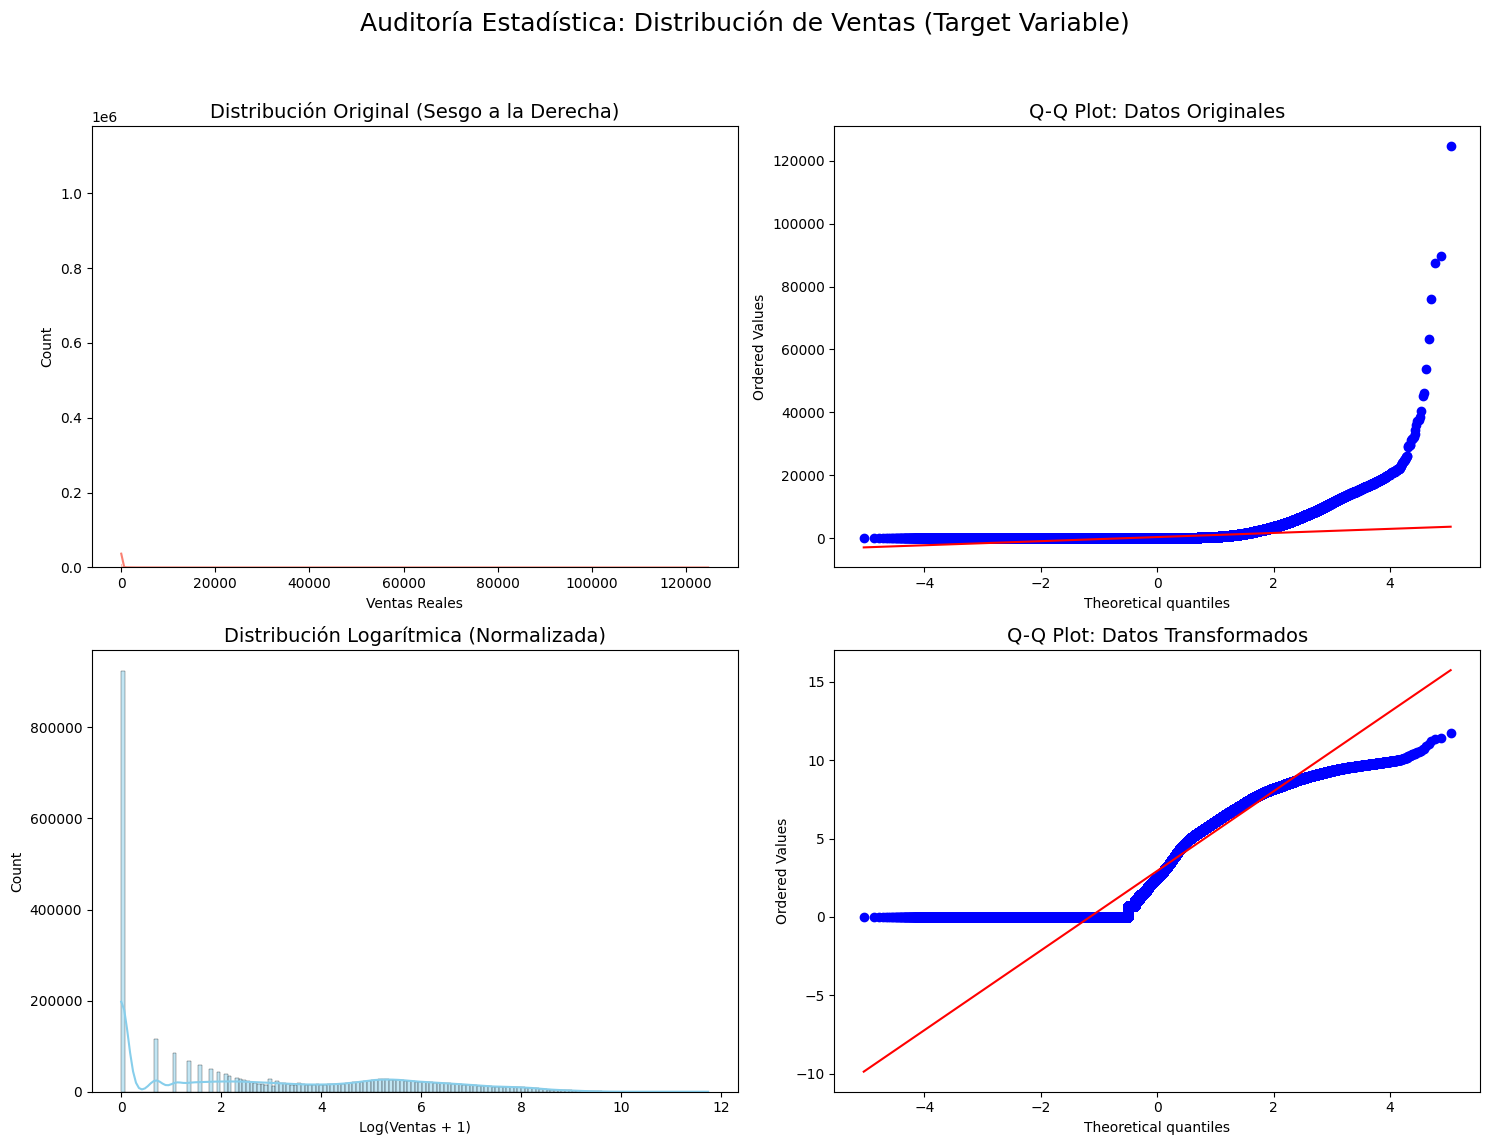

--- Diagnóstico de Sesgo (Skewness) ---
Sesgo Original: 7.35 (Valores > 1 indican alta asimetría)
Sesgo Transformado: 0.40 (Cercano a 0 indica simetría)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuración de la figura: 2 filas (Original vs Log) y 2 columnas (Histograma vs Q-Q Plot)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Auditoría Estadística: Distribución de Ventas (Target Variable)', fontsize=18)

# --- 1. DATOS ORIGINALES ---
# Histograma
sns.histplot(train['sales'], kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Distribución Original (Sesgo a la Derecha)', fontsize=14)
axes[0, 0].set_xlabel('Ventas Reales')

# Q-Q Plot (Gráfico Cúntil-Cuantil)
# Compara los datos contra una distribución normal teórica
stats.probplot(train['sales'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Datos Originales', fontsize=14)

# --- 2. DATOS TRANSFORMADOS (Log1p) ---
# Histograma
sns.histplot(y_log, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Distribución Logarítmica (Normalizada)', fontsize=14)
axes[1, 0].set_xlabel('Log(Ventas + 1)')

# Q-Q Plot
stats.probplot(y_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Datos Transformados', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Cálculo de Skewness (Sesgo) para el reporte
original_skew = train['sales'].skew()
log_skew = pd.Series(y_log).skew()

print(f"--- Diagnóstico de Sesgo (Skewness) ---")
print(f"Sesgo Original: {original_skew:.2f} (Valores > 1 indican alta asimetría)")
print(f"Sesgo Transformado: {log_skew:.2f} (Cercano a 0 indica simetría)")